In [5]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Figures definitives

## 1. Caracterització

In [2]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :active => Bool,

        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mm = 1.0 * besselk(0, r_eff / ll)

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) 

        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end
    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	F (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	G (Float64 agent)
	vy (Float64 agent)
	S (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if active
            v_run
        else
            v_tumble
        end
    Dr_tumble = 6.2
    Dr_total = if a

In [4]:
# ns = [0.0125, 0.025, 0.05, 0.1, 0.2]
steps = 100000
vel = [10.0, 20.0, 50.0, 60.0, 75.0, 80.0, 100.0]


# for n in ns
    for (idx, v) in enumerate(vel)
        println("Running n=$v")

        com = Community(
            fixed_source,
            N=500,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [100, 100]
        )   

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062

        com.v = v 

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = 1  

        com.α   = 6.0

        com.K = 2.0 

        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        # Dc = 10 
        # delta = 0.01

        # d = delta/((v/10)^2)

        #Canviar lambda

        com.DMedium = 10
        com.delta = 0.0001

        com.x = 2.5*sqrt(com.DMedium/com.delta)
        com.y = 2.5*sqrt(com.DMedium/com.delta)
        com.theta = rand(Uniform(0,2π),com.N)

        com.methyl .= 0.0
        com.Yp .= com.K


        loadToPlatform!(com, preallocateAgents=1000)
        
        outfile = @sprintf("fsb_v%s_l316_D.jld2", v)  ###CANVIARRR NOOM

        jldopen(outfile, "w") do file

            for step in 1:steps
                CellBasedModels.step!(com)

                stepname = @sprintf("step_%06d", step)
                g = JLD2.Group(file, stepname)

                # Agent-level arrays (length = N)
                g["x"] = copy(com.x)
                g["y"] = copy(com.y)
                g["theta"] = copy(com.theta)

    
            end
        end
    end
# end

Running n=10.0
Running n=20.0
Running n=50.0
Running n=60.0
Running n=75.0
Running n=80.0
Running n=100.0


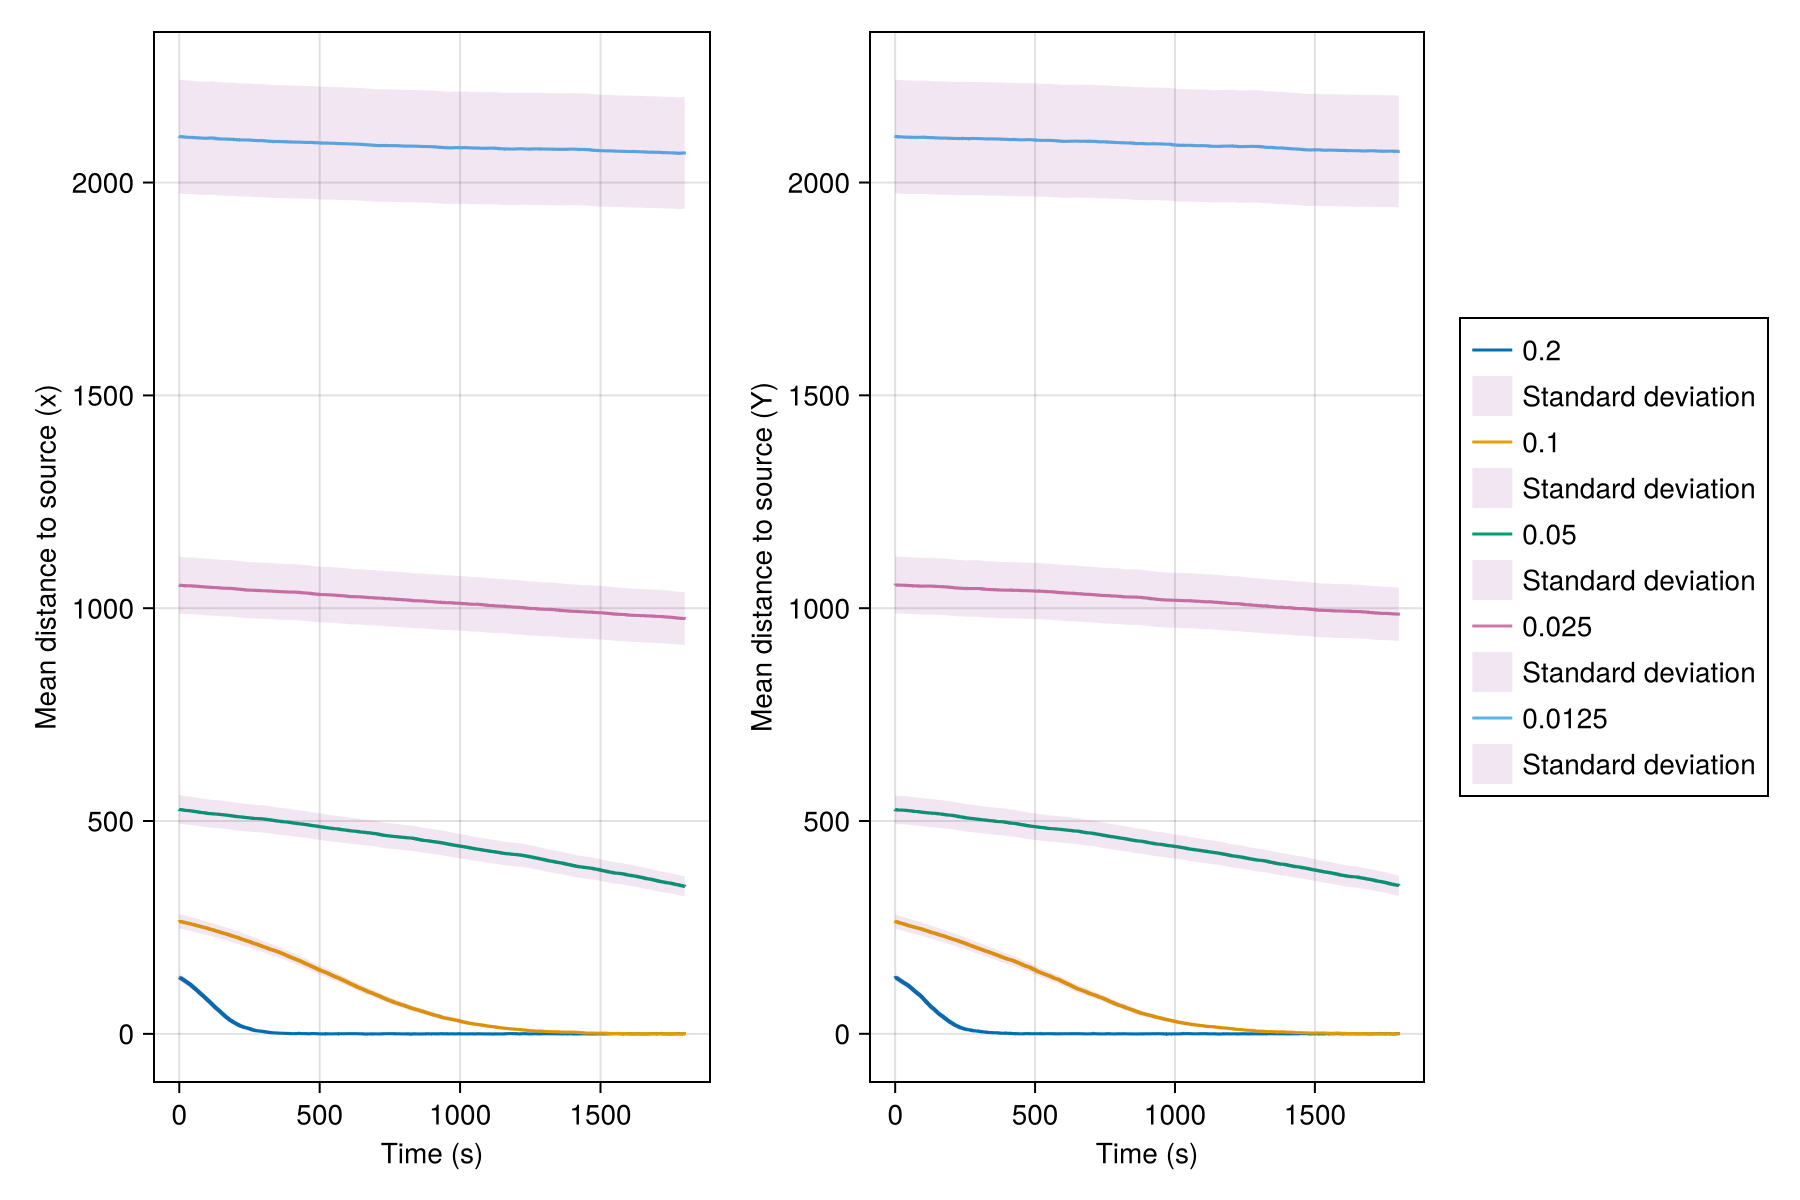

CairoMakie.Screen{IMAGE}


In [5]:
using CairoMakie
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")
steps = 180000

v = [10, 20, 50, 100]
ls = [0.2, 0.1, 0.05, 0.025, 0.0125]

for i in 1:length(ls)

    mean_dist_x = Float64[] 
    std_dist_x = Float64[]
    mean_dist_y = Float64[] 
    std_dist_y = Float64[]
    jldopen("fsb_v10.0_l$(ls[i])_k.jld2", "r") do file 

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            xs = 0
            ys = 0

            other_x = g["x"]

            other_y = g["y"]

            dists_x = other_x .- xs
            dists_y = other_y .- ys
            norm_x = dists_x
            norm_y = dists_y

            push!(mean_dist_x, mean(norm_x))
            push!(std_dist_x, std(norm_x))
            push!(mean_dist_y, mean(norm_y))
            push!(std_dist_y, std(norm_y))

        end

        std_X = std_dist_x ./ sqrt(500)
        std_Y = std_dist_y ./ sqrt(500)

        lines!(ax1, (1:steps)*0.01, mean_dist_x, label = "$(ls[i])")
        band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.1), label = "Standard deviation")
        
        lines!(ax2, (1:steps)*0.01, mean_dist_y)
        band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.1), label = "Standard deviation") 

    end
end
fig3[1,3] = Legend(fig3, ax1) 

display(fig3)

# Attractant fields l

In [ ]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

In [ ]:
xs, ys = 0.0, 0.0


len = Int(100 + 100)

x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(800 / 0.01)
# λ = sqrt(com.DMedium / com.delta)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

# Bacteria lambdas 05, 3, 10

In [10]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

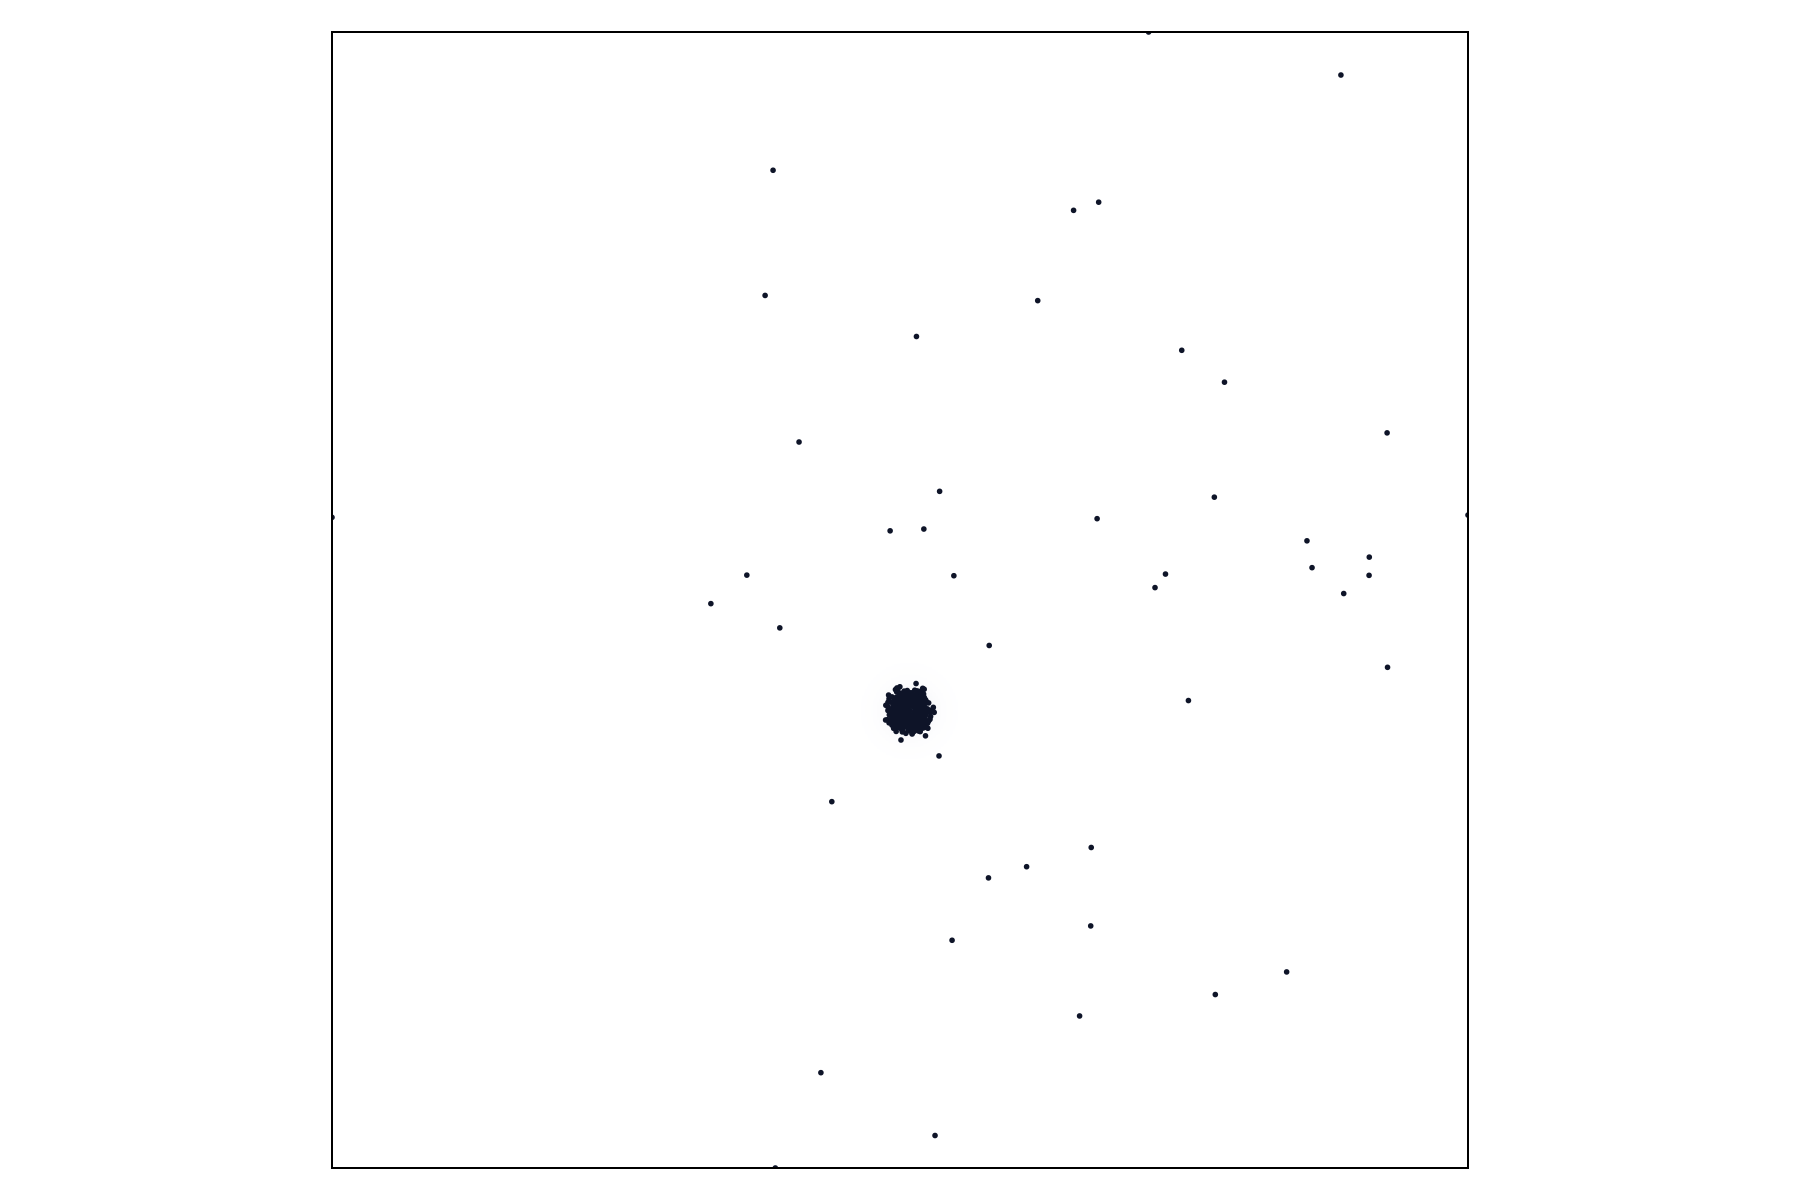

CairoMakie.Screen{IMAGE}


In [28]:
using CairoMakie
fig4 = Figure(size=(900,600))

dark = colorant"#645986"
bac = colorant"#0E1428"
dark2 = colorant"#7D84B2"
light = colorant"#F2EEF9"
white = colorant"#FFFFFF"
cmap = cgrad([white, dark2])

xs, ys = 0.0, 0.0
len = Int(100 + 100)

x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(2.5/ 0.04)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

jldopen("fsb_simulations/fsb_lambda_v10.0_l4.0.jld2", "r") do file 


        x = Vector{Float64}(undef, 1)
        y = Vector{Float64}(undef, 1)

        ax = Axis(fig4[1, 1], aspect=1)

        g = file[@sprintf("step_%06d", 60000)]
    

        heatmap!(ax, x_grid, y_grid, mm_grid, colormap=cmap)

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3

        for i in 1:length(x)
            scatter!(ax, x[i], y[i], color=bac, markersize=4)
        end

    hidedecorations!(ax)

end


display(fig4)

In [29]:
save("Plots/Fixed_source_model/Next/agents_n_4.svg", fig4)

CairoMakie.Screen{SVG}
